In [2]:
2**10

1024

In [3]:
# scipy, convert "C:\Users\101119\Documents\Sound Recordings\Recording (5).m4a" to spectrogram
# To convert an audio file (like "Recording (5).m4a") to a spectrogram using scipy, you can follow these steps:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
# test and run ffmpeg to convert m4a to wav
import subprocess
import os
from pathlib import Path

# subprocess.run(['ffmpeg', '-i', 'C:\\Users\\101119\\Documents\\Sound Recordings\\Recording (2).m4a', 'Recording.wav'])

In [4]:
import json
import math

def plot_spectrogram(audio_data, sample_rate, output_path):
    # Convert stereo/multi-channel audio to mono for spectrogram plotting
    audio_data = np.asarray(audio_data)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1)

    # Generate the spectrogram
    # frequencies, times, Sxx = spectrogram(audio_data, fs=sample_rate)
    frequencies, times, Sxx = spectrogram(
    audio_data,
    fs=sample_rate,
    window='hann',
    nperseg=4096//4,
    noverlap=3840//4, #3072,
    scaling='spectrum',
    mode='magnitude'
                        )

    # Plot the spectrogram
    plt.figure(figsize=(20, 6))
    # output_path = os.path.join(
    #     r"D:\DSAI-teaching\brahmansh",
    #     os.path.splitext(os.path.basename(wav_path))[0] + ".png"
    # )

    plt.imshow(
        # output_path,
        20 * np.log10(Sxx + 1e-12),
        origin="lower",
        cmap="viridis"      # optional
    )
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [s]')
    # plt.title(f'Spectrogram of {os.path.basename(wav_path)}')
    plt.colorbar(label='Intensity [dB]')
    # plt.ylim(0, 8000)  # Limit frequency axis to 8 kHz for better visibility
    plt.show()



In [5]:
subprocess.run(['ffmpeg', '-i', r"C:\Users\Brahmansh\Documents\Sound recordings\Recording (3).m4a", 'Recording.wav'])

CompletedProcess(args=['ffmpeg', '-i', 'C:\\Users\\Brahmansh\\Documents\\Sound recordings\\Recording (3).m4a', 'Recording.wav'], returncode=0)

In [6]:
sample_rate, wav_data = wav.read(r"Recording.wav")

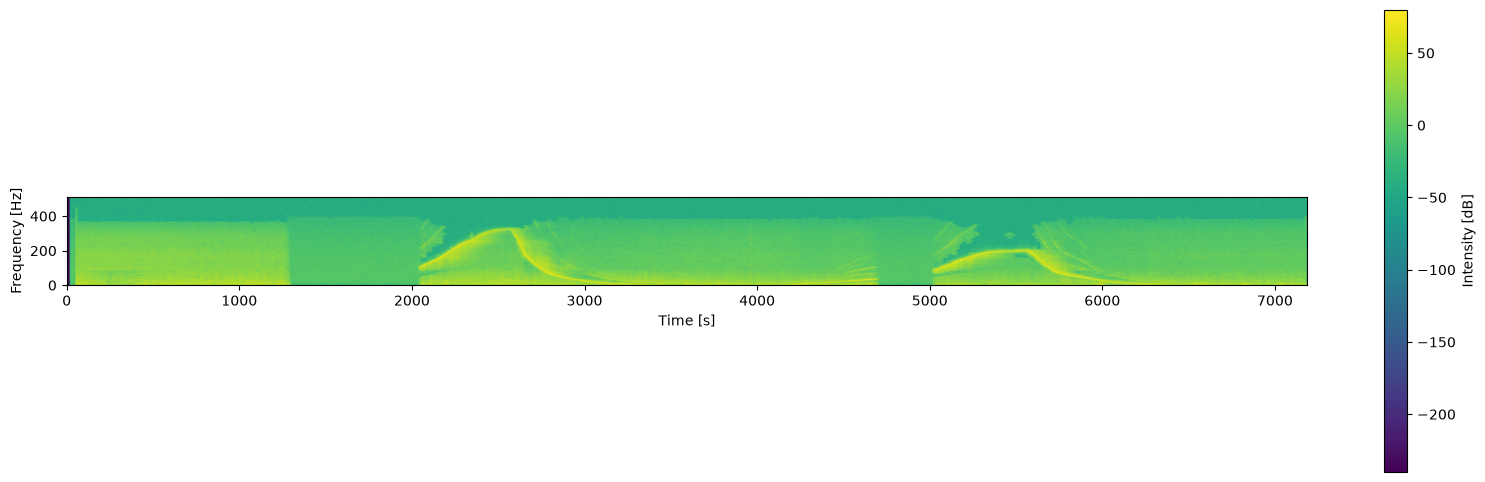

In [7]:
plot_spectrogram(audio_data=wav_data, sample_rate=sample_rate, output_path="test_clap.png")